Cell 1 - Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Cell 2 - Load Cleaned Datasets

In [43]:
products = pd.read_csv("../data/cleaned/products.csv")
inventory = pd.read_csv("../data/cleaned/inventory.csv")
sales_lines = pd.read_csv("../data/cleaned/sales_lines.csv")

Cell 3 - Dataset Overview

In [44]:
datasets = {
    "Products": products,
    "Inventory": inventory,
    "Sales Lines": sales_lines
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Products,30,25
1,Inventory,180,8
2,Sales Lines,130402,9


Cell 4 - Product Summary

In [45]:
print("PRODUCT SUMMARY")
print("-"*50)

print("Total Products :", products["product_id"].nunique())
print("Total Categories :", products["category"].nunique())
print("Total Brands :", products["brand"].nunique())
print("Total Machine Types :", products["machine_type"].nunique())

PRODUCT SUMMARY
--------------------------------------------------
Total Products : 30
Total Categories : 15
Total Brands : 6
Total Machine Types : 6


Cell 5 - Merge Product & Inventory Data

In [46]:
inventory_product = inventory.merge(
    products,
    on="product_id",
    how="left"
)

inventory_product.head()

,product_id,branch_id,opening_stock,reorder_level_x,safety_stock_x,max_stock,current_stock,warehouse_bin,product_name,category,machine_type,brand,model_compatibility,unit_cost,unit_price,margin_percentage,gst_rate,weight_kg,dimensions_cm,material_type,warranty_months,reorder_level_y,safety_stock_y,max_stock_level,lead_time_days,criticality_level,usage_frequency,uom,last_purchase_price,last_purchase_date,last_purchase_date_year,last_purchase_date_month
0,P001,Del001,196,59,46,340,115928,C15,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3
1,P001,Pun001,198,70,43,349,109389,D16,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3
2,P001,Chn001,187,62,44,311,99373,A11,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3
3,P001,Hyd001,226,71,65,417,108772,A10,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3
4,P001,Kol001,263,94,58,475,103808,F03,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3


Cell 6 - Inventory Value Calculation

In [47]:
inventory_product["inventory_value"] = (
    inventory_product["current_stock"] *
    inventory_product["unit_cost"]
)

inventory_product[[
    "product_id",
    "product_name",
    "current_stock",
    "unit_cost",
    "inventory_value"
]].head()

,product_id,product_name,current_stock,unit_cost,inventory_value
0,P001,Hydraulic Pump Hp-300,115928,18950,2196835600
1,P001,Hydraulic Pump Hp-300,109389,18950,2072921550
2,P001,Hydraulic Pump Hp-300,99373,18950,1883118350
3,P001,Hydraulic Pump Hp-300,108772,18950,2061229400
4,P001,Hydraulic Pump Hp-300,103808,18950,1967161600


Cell 7 - Inventory Summary

In [48]:
print("INVENTORY SUMMARY")
print("-"*50)

print("Total Current Stock :", inventory_product["current_stock"].sum())

print("Average Current Stock :", round(
    inventory_product["current_stock"].mean(),2))

print("Total Inventory Value : ₹",
      round(inventory_product["inventory_value"].sum(),2))

print("Average Inventory Value : ₹",
      round(inventory_product["inventory_value"].mean(),2))

INVENTORY SUMMARY
--------------------------------------------------
Total Current Stock : 19303266
Average Current Stock : 107240.37
Total Inventory Value : ₹ 281292677410
Average Inventory Value : ₹ 1562737096.72


Cell 8 - Top 10 Products by Inventory Value

In [49]:
top_inventory = inventory_product.sort_values(
    by="inventory_value",
    ascending=False
).head(10)

top_inventory[[
    "product_name",
    "category",
    "current_stock",
    "inventory_value"
]]

,product_name,category,current_stock,inventory_value
86,Engine Block Eb-600,Engine,113851,10872770500
87,Engine Block Eb-600,Engine,110035,10508342500
85,Engine Block Eb-600,Engine,106048,10127584000
89,Engine Block Eb-600,Engine,105135,10040392500
84,Engine Block Eb-600,Engine,100967,9642348500
88,Engine Block Eb-600,Engine,96547,9220238500
80,Transmission Assembly Ta-800,Transmission,114302,7829687000
79,Transmission Assembly Ta-800,Transmission,113386,7766941000
78,Transmission Assembly Ta-800,Transmission,111321,7625488500
81,Transmission Assembly Ta-800,Transmission,111315,7625077500


Cell 9 - Visualization (Top Inventory Value)

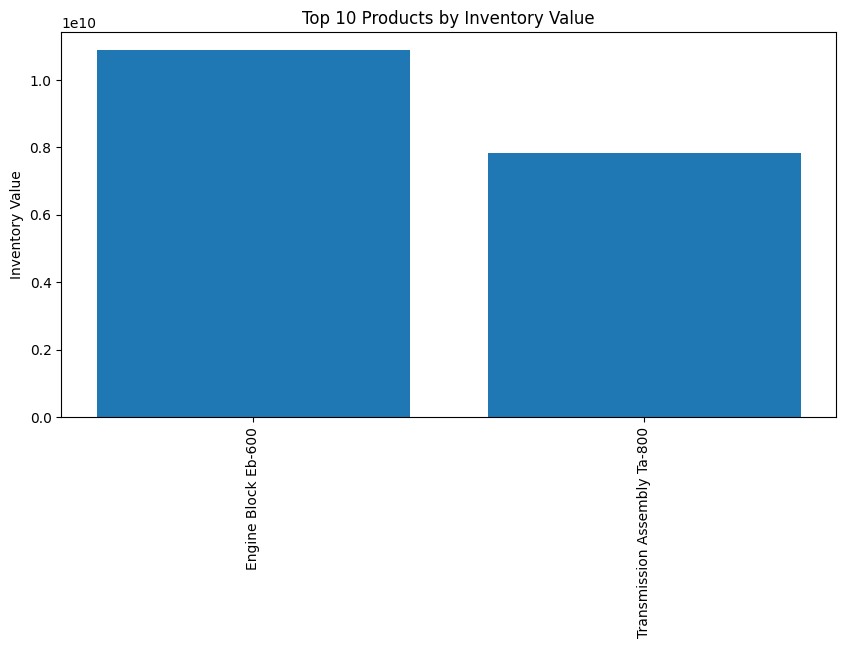

In [50]:
plt.figure(figsize=(10,5))

plt.bar(
    top_inventory["product_name"],
    top_inventory["inventory_value"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Products by Inventory Value")

plt.ylabel("Inventory Value")

plt.show()

Cell 10 - Bottom 10 Products by Inventory Value

In [51]:
bottom_inventory = inventory_product.sort_values(
    by="inventory_value"
).head(10)

bottom_inventory[[
    "product_name",
    "category",
    "current_stock",
    "inventory_value"
]]

,product_name,category,current_stock,inventory_value
154,Grease Cartridge Gc-5,Lubricants,101412,18254160
150,Grease Cartridge Gc-5,Lubricants,103678,18662040
155,Grease Cartridge Gc-5,Lubricants,103793,18682740
151,Grease Cartridge Gc-5,Lubricants,105190,18934200
153,Grease Cartridge Gc-5,Lubricants,108348,19502640
152,Grease Cartridge Gc-5,Lubricants,108895,19601100
158,O-Ring Set Or-50,Seals,97973,25472980
160,O-Ring Set Or-50,Seals,100477,26124020
159,O-Ring Set Or-50,Seals,104746,27233960
156,O-Ring Set Or-50,Seals,106775,27761500


Cell 11 - Zero Stock Products

In [52]:
zero_stock = inventory_product[
    inventory_product["current_stock"] == 0
]

print("Products with Zero Stock :", len(zero_stock))

zero_stock[[
    "product_name",
    "category",
    "current_stock"
]].head(20)

Products with Zero Stock : 0


,product_name,category,current_stock


Cell 12 - Category-wise Inventory Value

In [53]:
category_inventory = inventory_product.groupby(
    "category"
)["inventory_value"].sum().sort_values(ascending=False)

category_inventory

category
Engine           94074806700
Hydraulic        76980735240
Transmission     45323915500
Undercarriage    37039171200
Electrical       13738763250
Cooling           4944888000
Cabin             3649973600
Sensors           1746189500
Brakes            1193592600
Filters            827849700
Seals              766908660
Pins & Bushes      468949500
Attachments        212395960
Belts              210901120
Lubricants         113636880
Name: inventory_value, dtype: int64

Cell 13 - Visualization

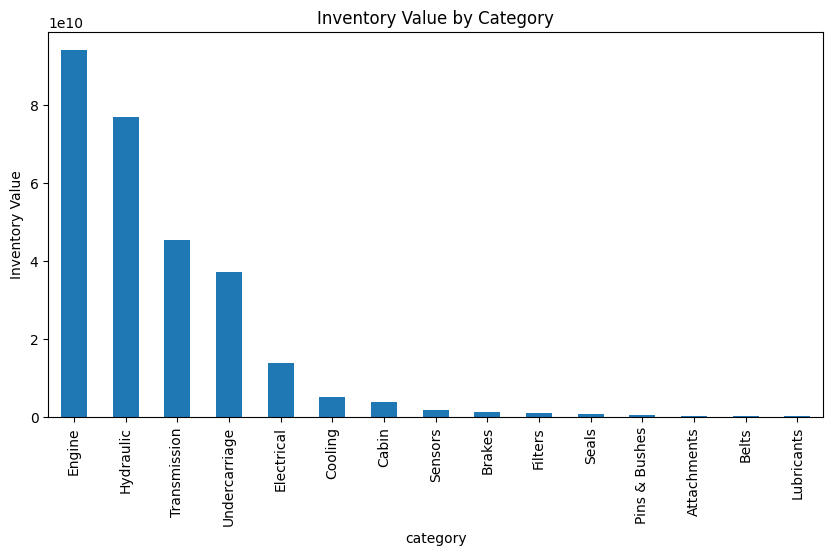

In [54]:
plt.figure(figsize=(10,5))

category_inventory.plot(kind="bar")

plt.title("Inventory Value by Category")

plt.ylabel("Inventory Value")

plt.show()

Cell 14 - Sales Summary by Product

In [55]:
sales_summary = sales_lines.groupby("product_id").agg(
    total_quantity=("quantity", "sum"),
    total_sales=("line_grand_total", "sum")
).reset_index()

sales_summary.head()

,product_id,total_quantity,total_sales
0,P001,45389,1.423399e+09
1,P002,45342,3.852256e+07
2,P003,45684,6.738390e+07
3,P004,45575,2.321773e+09
4,P005,45026,4.870012e+08


Cell 15 - Merge Sales with Product Details

In [56]:
product_sales = sales_summary.merge(
    products,
    on="product_id",
    how="left"
)

product_sales.head()

,product_id,total_quantity,total_sales,product_name,category,machine_type,brand,model_compatibility,unit_cost,unit_price,margin_percentage,gst_rate,weight_kg,dimensions_cm,material_type,warranty_months,reorder_level,safety_stock,max_stock_level,lead_time_days,criticality_level,usage_frequency,uom,last_purchase_price,last_purchase_date,last_purchase_date_year,last_purchase_date_month
0,P001,45389,1.423399e+09,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3
1,P002,45342,3.852256e+07,Engine Oil Filter Of-90,Filters,Loader,Jcb,Jcb 3Dx,450,720,37.3,18,0.4,10X8X8,Paper,6,80,40,200,7,Medium,High,Piece,430,2019-07-22,2019,7
2,P003,45684,6.738390e+07,Air Filter Af-120,Filters,Excavator,Komatsu,Komatsu Pc210,820,1250,52.4,18,0.8,18X12X12,Synthetic,6,60,30,150,7,Medium,High,Piece,800,2020-01-10,2020,1
3,P004,45575,2.321773e+09,Track Chain Tc-45,Undercarriage,Bulldozer,Volvo,Volvo D6,32500,39800,22.5,28,210.0,180X40X35,Steel,18,8,4,20,30,High,Low,Set,32000,2020-06-18,2020,6
4,P005,45026,4.870012e+08,Fuel Injector Fi-220,Engine,Excavator,Tata Hitachi,Tata Hitachi Ex 200,6350,8450,33.0,28,1.2,20X12X12,Alloy,12,30,15,80,18,High,Medium,Piece,6200,2020-11-05,2020,11


Cell 16 - Top 10 Fast Moving Products

In [57]:
fast_moving = product_sales.sort_values(
    by="total_quantity",
    ascending=False
).head(10)

fast_moving[[
    "product_name",
    "category",
    "total_quantity",
    "total_sales"
]]

,product_name,category,total_quantity,total_sales
28,Pressure Sensor Ps-90,Sensors,47066,2.193746e+08
9,Turbocharger Tb-900,Engine,46964,2.097976e+09
5,Alternator Alt-500,Electrical,46731,6.699356e+08
10,Hydraulic Cylinder Hc-200,Hydraulic,46612,1.646709e+09
6,Hydraulic Hose Hh-60,Hydraulic,46468,7.950675e+07
20,Boom Cylinder Bc-400,Hydraulic,46364,2.741782e+09
15,Radiator Rd-250,Cooling,46306,5.573390e+08
27,Light Assembly La-18,Electrical,46164,1.225654e+08
11,Brake Pad Bp-40,Brakes,45972,1.441682e+08
18,Swing Motor Swm-350,Hydraulic,45971,2.341947e+09


Cell 17 - Visualization

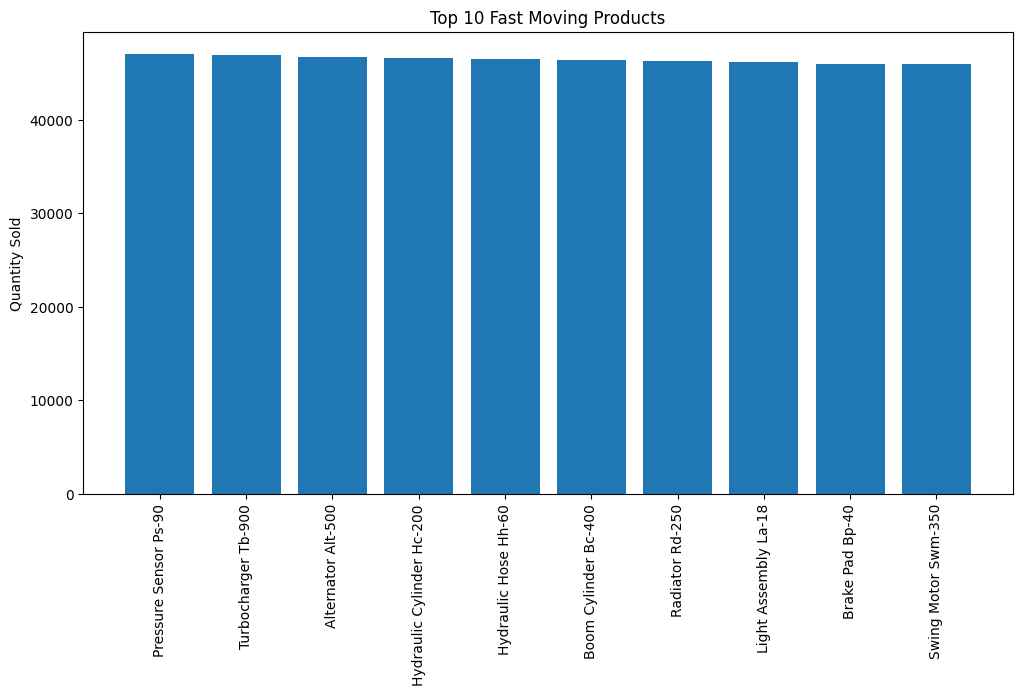

In [58]:
plt.figure(figsize=(12,6))

plt.bar(
    fast_moving["product_name"],
    fast_moving["total_quantity"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Fast Moving Products")

plt.ylabel("Quantity Sold")

plt.show()

Cell 18 - Slow Moving Products

In [59]:
slow_moving = product_sales.sort_values(
    by="total_quantity",
    ascending=True
).head(10)

slow_moving[[
    "product_name",
    "category",
    "total_quantity",
    "total_sales"
]]

,product_name,category,total_quantity,total_sales
23,Track Roller Tr-60,Undercarriage,44022,5.803860e+08
12,Seal Kit Sk-15,Seals,44081,7.542259e+07
22,Idler Wheel Iw-55,Undercarriage,44437,7.365877e+08
25,Grease Cartridge Gc-5,Lubricants,44844,1.640394e+07
8,Starter Motor Sm-700,Electrical,44946,8.572101e+08
4,Fuel Injector Fi-220,Engine,45026,4.870012e+08
17,Wheel Rim Wr-24,Undercarriage,45027,6.512705e+08
13,Transmission Assembly Ta-800,Transmission,45035,4.813341e+09
14,Engine Block Eb-600,Engine,45222,6.888215e+09
19,Pivot Pin Pp-12,Pins & Bushes,45340,6.152638e+07


Cell 19 - Top Revenue Products

In [60]:
top_revenue = product_sales.sort_values(
    by="total_sales",
    ascending=False
).head(10)

top_revenue[[
    "product_name",
    "category",
    "total_sales"
]]

,product_name,category,total_sales
14,Engine Block Eb-600,Engine,6.888215e+09
13,Transmission Assembly Ta-800,Transmission,4.813341e+09
20,Boom Cylinder Bc-400,Hydraulic,2.741782e+09
18,Swing Motor Swm-350,Hydraulic,2.341947e+09
3,Track Chain Tc-45,Undercarriage,2.321773e+09
9,Turbocharger Tb-900,Engine,2.097976e+09
10,Hydraulic Cylinder Hc-200,Hydraulic,1.646709e+09
0,Hydraulic Pump Hp-300,Hydraulic,1.423399e+09
29,Fuel Pump Fp-350,Engine,1.286585e+09
21,Control Valve Cv-75,Hydraulic,9.911566e+08


Cell 20 - ABC Analysis

In [61]:
abc = inventory_product[[
    "product_name",
    "inventory_value"
]].sort_values(
    by="inventory_value",
    ascending=False
)

abc["percentage"] = (
    abc["inventory_value"] /
    abc["inventory_value"].sum()
) * 100

abc["cumulative"] = abc["percentage"].cumsum()

abc["ABC_Class"] = np.where(
    abc["cumulative"] <= 80,
    "A",
    np.where(
        abc["cumulative"] <= 95,
        "B",
        "C"
    )
)

abc.head()

,product_name,inventory_value,percentage,cumulative,ABC_Class
86,Engine Block Eb-600,10872770500,3.865287,3.865287,A
87,Engine Block Eb-600,10508342500,3.735733,7.601020,A
85,Engine Block Eb-600,10127584000,3.600372,11.201393,A
89,Engine Block Eb-600,10040392500,3.569376,14.770768,A
84,Engine Block Eb-600,9642348500,3.427870,18.198639,A


Cell 21 - ABC Summary

In [62]:
abc.groupby("ABC_Class").size().reset_index(name="Products")

,ABC_Class,Products
0,A,54
1,B,43
2,C,83


Cell 22 - ABC Chart

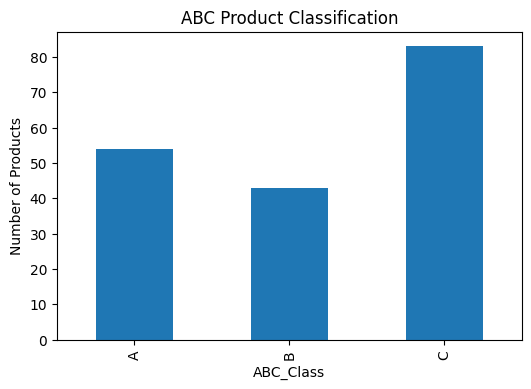

In [63]:
plt.figure(figsize=(6,4))

abc.groupby("ABC_Class").size().plot(kind="bar")

plt.title("ABC Product Classification")

plt.ylabel("Number of Products")

plt.show()

Cell 23 - Inventory Health

In [64]:
conditions = [
    inventory_product["current_stock"] < inventory_product["reorder_level_x"],
    inventory_product["current_stock"] > inventory_product["max_stock"]
]

choices = [
    "Understock",
    "Overstock"
]

inventory_product["Inventory_Status"] = np.select(
    conditions,
    choices,
    default="Normal"
)

inventory_product[[
    "product_name",
    "current_stock",
    "reorder_level_x",
    "max_stock",
    "Inventory_Status"
]].head()



,product_name,current_stock,reorder_level_x,max_stock,Inventory_Status
0,Hydraulic Pump Hp-300,115928,59,340,Overstock
1,Hydraulic Pump Hp-300,109389,70,349,Overstock
2,Hydraulic Pump Hp-300,99373,62,311,Overstock
3,Hydraulic Pump Hp-300,108772,71,417,Overstock
4,Hydraulic Pump Hp-300,103808,94,475,Overstock


Cell 24 - Inventory Status Summary

In [65]:
inventory_product["Inventory_Status"].value_counts()

Inventory_Status
Overstock    180
Name: count, dtype: int64

Cell 25 - Inventory Status Chart

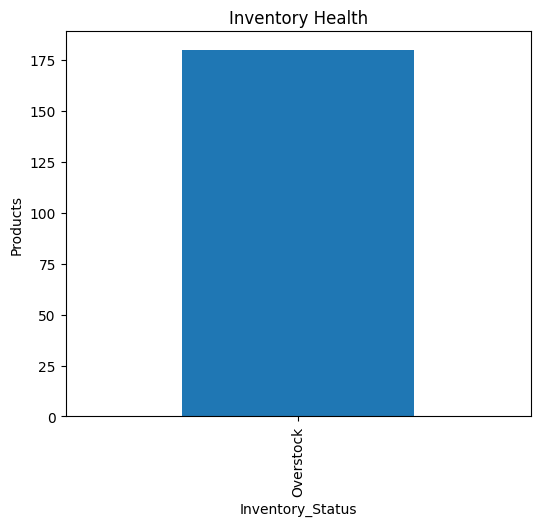

In [66]:
plt.figure(figsize=(6,5))

inventory_product["Inventory_Status"].value_counts().plot(
    kind="bar"
)

plt.title("Inventory Health")

plt.ylabel("Products")

plt.show()

Cell 26 - Top 10 Most Expensive Products

In [67]:
products.sort_values(
    by="unit_cost",
    ascending=False
)[[
    "product_name",
    "brand",
    "unit_cost"
]].head(10)

,product_name,brand,unit_cost
14,Engine Block Eb-600,Komatsu,95500
13,Transmission Assembly Ta-800,Volvo,68500
20,Boom Cylinder Bc-400,Komatsu,35600
3,Track Chain Tc-45,Volvo,32500
18,Swing Motor Swm-350,Volvo,31200
9,Turbocharger Tb-900,Cat,28900
10,Hydraulic Cylinder Hc-200,Tata Hitachi,21500
0,Hydraulic Pump Hp-300,Cat,18950
29,Fuel Pump Fp-350,Volvo,16400
21,Control Valve Cv-75,Cat,12800


Cell 27 - Highest Margin Products

In [68]:
products.sort_values(
    by="margin_percentage",
    ascending=False
)[[
    "product_name",
    "margin_percentage"
]].head(10)

,product_name,margin_percentage
26,O-Ring Set Or-50,84.6
25,Grease Cartridge Gc-5,72.2
7,Bucket Tooth Bt-10,70.6
16,Fan Belt Fb-30,62.5
27,Light Assembly La-18,55.2
19,Pivot Pin Pp-12,53.3
12,Seal Kit Sk-15,52.6
2,Air Filter Af-120,52.4
6,Hydraulic Hose Hh-60,48.0
28,Pressure Sensor Ps-90,43.6


Cell 28 - Business Insights

In [69]:
print("BUSINESS INSIGHTS")
print("-"*60)

print(f"Total Products : {products['product_id'].nunique()}")

print(f"Inventory Value : ₹ {inventory_product['inventory_value'].sum():,.2f}")

print(f"Fast Moving Products : {len(fast_moving)}")

print(f"Slow Moving Products : {len(slow_moving)}")

print(f"Products Understock : {(inventory_product['Inventory_Status']=='Understock').sum()}")

print(f"Products Overstock : {(inventory_product['Inventory_Status']=='Overstock').sum()}")

BUSINESS INSIGHTS
------------------------------------------------------------
Total Products : 30
Inventory Value : ₹ 281,292,677,410.00
Fast Moving Products : 10
Slow Moving Products : 10
Products Understock : 0
Products Overstock : 180


Cell 29 - Recommendations

In [70]:
recommendations = [
    "Increase stock for fast-moving products.",
    "Review slow-moving products for promotional offers.",
    "Reduce overstocked inventory to lower holding costs.",
    "Prioritize Class A products for inventory monitoring.",
    "Monitor products below reorder level."
]

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

1. Increase stock for fast-moving products.
2. Review slow-moving products for promotional offers.
3. Reduce overstocked inventory to lower holding costs.
4. Prioritize Class A products for inventory monitoring.
5. Monitor products below reorder level.


Cell 30 - Week 3 Summary

In [71]:
summary = pd.DataFrame({
    "Metric":[
        "Total Products",
        "Inventory Value",
        "Fast Moving Products",
        "Slow Moving Products",
        "ABC Categories"
    ],
    "Value":[
        products["product_id"].nunique(),
        round(inventory_product["inventory_value"].sum(),2),
        len(fast_moving),
        len(slow_moving),
        abc["ABC_Class"].nunique()
    ]
})

summary

,Metric,Value
0,Total Products,30
1,Inventory Value,281292677410
2,Fast Moving Products,10
3,Slow Moving Products,10
4,ABC Categories,3
